# 인공지능수학 5주차: 다변수 선형회귀 — 행렬로 읽는 예측과 gradient


> **이번 주 목표**
> - $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$를 선형 변환(2주차)으로 읽을 수 있다
> - 손실 등고선이 타원이 되는 이유를 이해하고, 정규화가 왜 필요한지 직관을 얻는다
> - gradient 공식 $\nabla L = \frac{2}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$에서 $\mathbf{X}^T$가 왜 나오는지 기하적으로 이해한다
> - 1변수와 다변수 경사하강법 코드가 왜 동일한지 확인한다

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

---
## 🎯 Aha Moment: 코드는 그대로인데 특성이 늘어난다

1변수 선형회귀 코드와 다변수 선형회귀 코드를 비교합니다.  
특성 수가 1개에서 4개로 늘어도 **학습 코드가 한 줄도 바뀌지 않습니다.**  
왜 그럴 수 있을까요?

In [10]:
# ---- Aha Moment: same code, different number of features ----
np.random.seed(0)
m = 60   # samples

# True relationship: y = 3*x1 - 2*x2 + 1.5*x3 - x4 + noise
X_full = np.random.randn(m, 4)
y_true = 3*X_full[:,0] - 2*X_full[:,1] + 1.5*X_full[:,2] - X_full[:,3]
y = y_true + np.random.randn(m)*0.5

def gd(X, y, lr=0.01, n_iter=500):
    """Gradient descent — works for ANY number of features."""
    m, n = X.shape
    w = np.zeros(n)
    losses = []
    for _ in range(n_iter):
        residual = X @ w - y
        grad = (2/m) * X.T @ residual    # this line handles 1 or 100 features identically
        w = w - lr * grad
        losses.append(np.mean(residual**2))
    return w, losses

results = {}
for n_feat in [1, 2, 4]:  # 특성 수 달라질 때 비교할 목적
    # Normalize + bias trick
    X_n = X_full[:, :n_feat]
    X_n = (X_n - X_n.mean(axis=0)) / X_n.std(axis=0)
    X_b = np.hstack([np.ones((m, 1)), X_n])
    w, losses = gd(X_b, y)
    results[n_feat] = (w, losses)
    print(f'{n_feat} feature(s): final MSE = {losses[-1]:.4f}')

print('\n핵심: gd() 함수는 어느 경우에도 변하지 않았습니다.')

1 feature(s): final MSE = 5.5779
2 feature(s): final MSE = 2.3738
4 feature(s): final MSE = 0.2392

핵심: gd() 함수는 어느 경우에도 변하지 않았습니다.


> **질문:** 특성이 1개든 4개든 $\mathbf{X}^T\mathbf{r}$ 한 줄로 gradient를 구할 수 있는 이유가 무엇일까요?  
> 👉 *이번 수업에서 $\mathbf{X}^T$가 하는 일을 수학적으로 열겠습니다.*

---
## 1. $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$: Lecture 2 연결

### 1-1. 예측을 두 가지 방식으로 읽기

2주차에서 배웠습니다: 행렬-벡터 곱은 **열의 선형결합**입니다.

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} = \begin{bmatrix} | & | & | \\ \mathbf{x}_1 & \mathbf{x}_2 & \mathbf{x}_3 \\ | & | & | \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \\ w_3 \end{bmatrix} = w_1 \mathbf{x}_1 + w_2 \mathbf{x}_2 + w_3 \mathbf{x}_3$$

여기서 $\mathbf{x}_j$는 **$j$번째 특성의 모든 샘플값을 담은 열 벡터** (길이 $m$)입니다.

| 기호 | 의미 | &nbsp;&nbsp;&nbsp;&nbsp; shape &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|------|------|-------|
| $\mathbf{X}$ | 설계 행렬 (bias 열 포함) | $(m, n+1)$ |
| $\mathbf{w}$ | 가중치 벡터 (bias 포함) | $(n+1,)$ |
| $\hat{\mathbf{y}}$ | 예측값 벡터 (모든 샘플) | $(m,)$ |
| $\mathbf{x}_j$ | $j$번째 특성 열 | $(m,)$ |

**직관:** 예측값 $\hat{\mathbf{y}}$는 각 특성 열을 가중치만큼 섞어서 만든 벡터입니다.  
$w_j$가 클수록 $j$번째 특성이 예측에 더 많이 기여합니다.

In [11]:
# ---- Xw = linear combination of columns ----
# Small example: 4 samples, 2 features (+ bias)
X = np.array([[1, 2, -1],
              [1, 0,  3],
              [1, 1,  1],
              [1, 4, -2]])   # shape (4, 3): bias, feat1, feat2

w = np.array([0.5, 1.0, -0.5])  # [bias, w1, w2]

# Method 1: matrix multiply
y_hat_mm = X @ w

# Method 2: linear combination of columns
y_hat_lc = w[0]*X[:,0] + w[1]*X[:,1] + w[2]*X[:,2]

print('X @ w              :', y_hat_mm)
print('linear combination :', y_hat_lc)
print('Same?              :', np.allclose(y_hat_mm, y_hat_lc))
print()
print('Interpretation:')
print(f'  Each prediction = {w[0]}*(1) + {w[1]}*(feat1) + {w[2]}*(feat2)')
print(f'  Sample 1: {w[0]}*1 + {w[1]}*{X[0,1]} + {w[2]}*{X[0,2]} = {y_hat_mm[0]}')

X @ w              : [ 3.  -1.   1.   5.5]
linear combination : [ 3.  -1.   1.   5.5]
Same?              : True

Interpretation:
  Each prediction = 0.5*(1) + 1.0*(feat1) + -0.5*(feat2)
  Sample 1: 0.5*1 + 1.0*2 + -0.5*-1 = 3.0


### 1-2. $\mathbf{X}$는 $m$차원 공간에서의 변환

2주차에서 배운 관점: $\mathbf{X}$는 가중치 벡터 $\mathbf{w}$를 받아서 예측 벡터 $\hat{\mathbf{y}}$를 만드는 **선형 변환**입니다.

$$\mathbf{w} \in \mathbb{R}^{n+1} \xrightarrow{\mathbf{X}} \hat{\mathbf{y}} \in \mathbb{R}^m$$

- **입력 공간**: 가중치 공간 ($n+1$차원) — 우리가 조정하는 파라미터
- **출력 공간**: 예측 공간 ($m$차원) — 각 샘플의 예측값

$\mathbf{w}$를 바꾸면 예측 벡터 $\hat{\mathbf{y}}$가 $m$차원 공간에서 이동합니다.  
학습의 목표: $\hat{\mathbf{y}}$를 실제값 $\mathbf{y}$에 최대한 가깝게 만드는 $\mathbf{w}$를 찾기.

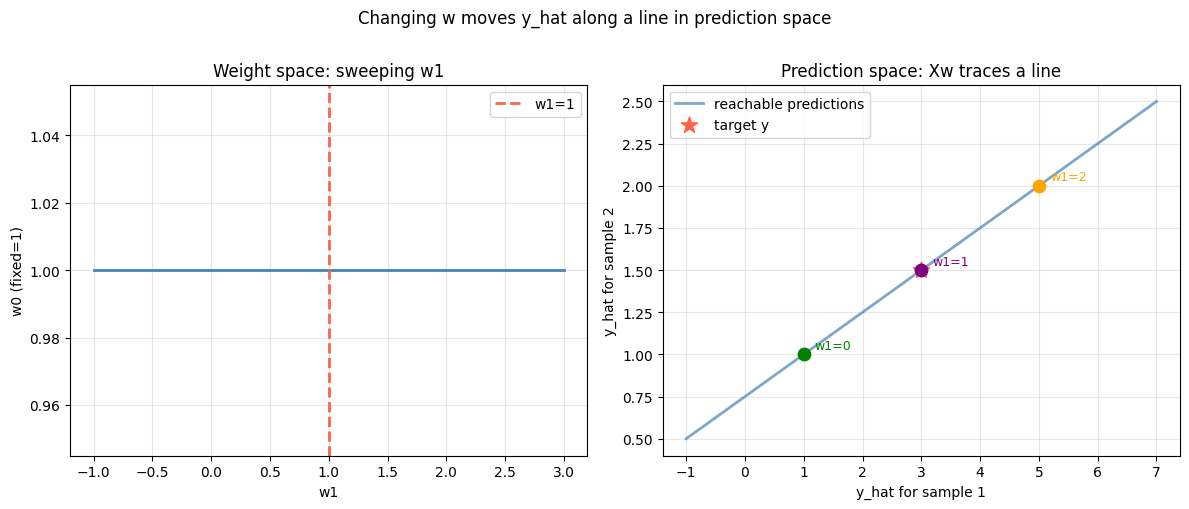

In [12]:
# ---- Visualize: changing w moves y_hat in m-dimensional space ----
# With 2 samples, we can plot in 2D
X_2 = np.array([[1, 2.0],
                [1, 0.5]])   # shape (2, 2): bias + 1 feature
y_2 = np.array([3.0, 1.5])  # true values (target)

# Sweep w1 (feature weight) while keeping bias=1
w1_range = np.linspace(-1, 3, 50)
y_hat_paths = np.array([X_2 @ np.array([1.0, w1]) for w1 in w1_range])  # (50, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: weight space
axes[0].plot(w1_range, w1_range*0+1, 'steelblue', lw=2)  # w0=1 fixed
axes[0].axvline(x=1.0, color='tomato', lw=2, ls='--', label='w1=1')
axes[0].set_xlabel('w1'); axes[0].set_ylabel('w0 (fixed=1)')
axes[0].set_title('Weight space: sweeping w1')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: prediction space (2D because m=2)
axes[1].plot(y_hat_paths[:,0], y_hat_paths[:,1],
             'steelblue', lw=2, alpha=0.7, label='reachable predictions')
axes[1].scatter(*y_2, color='tomato', s=150, zorder=5, label='target y', marker='*')
# Mark a few specific w1 values
for w1_mark, col in [(0,'green'),(1,'purple'),(2,'orange')]:
    yh = X_2 @ np.array([1.0, w1_mark])
    axes[1].scatter(*yh, color=col, s=80, zorder=5)
    axes[1].annotate(f'w1={w1_mark}', yh, textcoords='offset points',
                     xytext=(8, 4), fontsize=9, color=col)
axes[1].set_xlabel('y_hat for sample 1')
axes[1].set_ylabel('y_hat for sample 2')
axes[1].set_title('Prediction space: Xw traces a line')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Changing w moves y_hat along a line in prediction space', y=1.01)
plt.tight_layout()
plt.show()

**핵심 관찰:** $\mathbf{w}$가 달라져도 $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$는 $m$차원 공간에서 **직선(선형 부분공간)** 위만 움직입니다.  
이것이 바로 *선형* 회귀인 이유입니다. 학습은 이 직선 위에서 $\mathbf{y}$와 가장 가까운 점을 찾는 과정입니다.

---
## 2. 손실 등고선과 특성 정규화

### 2-1. 손실 함수의 모양: 왜 타원인가?

2변수 가중치 $(w_1, w_2)$에 대한 MSE 손실을 등고선으로 그려봅니다.

MSE를 $\mathbf{w}$에 대해 정리하면:

$$L(\mathbf{w}) = \frac{1}{m}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2$$

이 함수는 $\mathbf{w}$에 대한 **이차형식(quadratic form)**입니다.  
이차함수의 등고선은 **타원**이고, 타원의 모양은 특성의 스케일에 따라 결정됩니다.

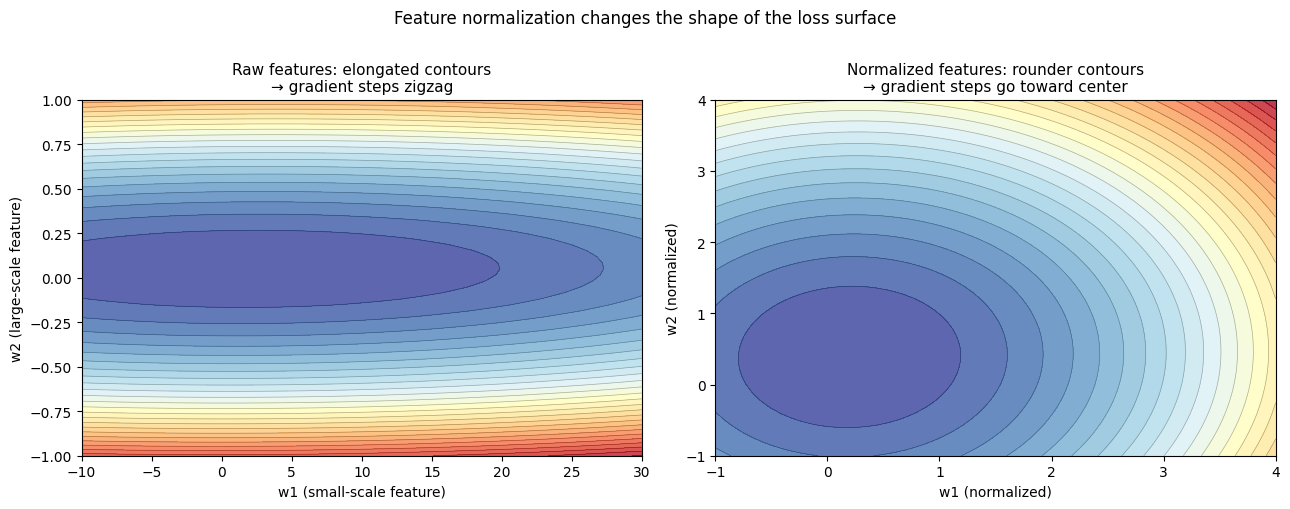

In [13]:
# ---- Loss contours: raw vs normalized features ----
np.random.seed(1)
m_c = 50

# Case 1: features on very different scales
x1_raw = np.random.randn(m_c) * 0.1    # small scale
x2_raw = np.random.randn(m_c) * 10.0   # large scale
y_c    = 2*x1_raw + 0.05*x2_raw + np.random.randn(m_c)*0.1

X_raw  = np.column_stack([x1_raw, x2_raw])
X_norm = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

def mse_grid(X, y, w1_range, w2_range):
    """Compute MSE over a grid of (w1, w2) values."""
    W1, W2 = np.meshgrid(w1_range, w2_range)
    Z = np.zeros_like(W1)
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.array([W1[i,j], W2[i,j]])
            Z[i,j] = np.mean((X @ w - y)**2)
    return W1, W2, Z

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw features: very elongated ellipse
W1, W2, Z = mse_grid(X_raw, y_c,
                      np.linspace(-10, 30, 60),
                      np.linspace(-1, 1, 60))
axes[0].contourf(W1, W2, Z, levels=30, cmap='RdYlBu_r', alpha=0.8)
axes[0].contour( W1, W2, Z, levels=30, colors='k', alpha=0.3, linewidths=0.5)
axes[0].set_xlabel('w1 (small-scale feature)'); axes[0].set_ylabel('w2 (large-scale feature)')
axes[0].set_title('Raw features: elongated contours\n→ gradient steps zigzag', fontsize=11)

# Normalized features: near-circular ellipse
W1n, W2n, Zn = mse_grid(X_norm, y_c,
                         np.linspace(-1, 4, 60),
                         np.linspace(-1, 4, 60))
axes[1].contourf(W1n, W2n, Zn, levels=30, cmap='RdYlBu_r', alpha=0.8)
axes[1].contour( W1n, W2n, Zn, levels=30, colors='k', alpha=0.3, linewidths=0.5)
axes[1].set_xlabel('w1 (normalized)'); axes[1].set_ylabel('w2 (normalized)')
axes[1].set_title('Normalized features: rounder contours\n→ gradient steps go toward center', fontsize=11)

plt.suptitle('Feature normalization changes the shape of the loss surface', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2-2. 왜 타원이 문제인가?

Gradient는 등고선에 **수직**으로 향합니다. 타원이 길쭉할수록:

- 좁은 방향(급경사): gradient가 크고 빠르게 이동 → **발산 위험**
- 넓은 방향(완만한 경사): gradient가 작아서 수렴이 느림

결과적으로 경사하강법이 **지그재그**로 이동하며 수렴이 매우 느려집니다.

**표준화(standardization)가 하는 일:**  
모든 특성의 스케일을 맞춰줘서 등고선이 **원에 가깝게** 됩니다.  
그러면 gradient 방향이 항상 최솟값 쪽을 바라보고, 수렴이 빠릅니다.

$$x_{j, \text{norm}} = \frac{x_j - \mu_j}{\sigma_j}$$

여기서 $\mu_j, \sigma_j$는 반드시 **훈련 데이터**에서만 계산합니다. (이유는 Lecture6에서 설명)

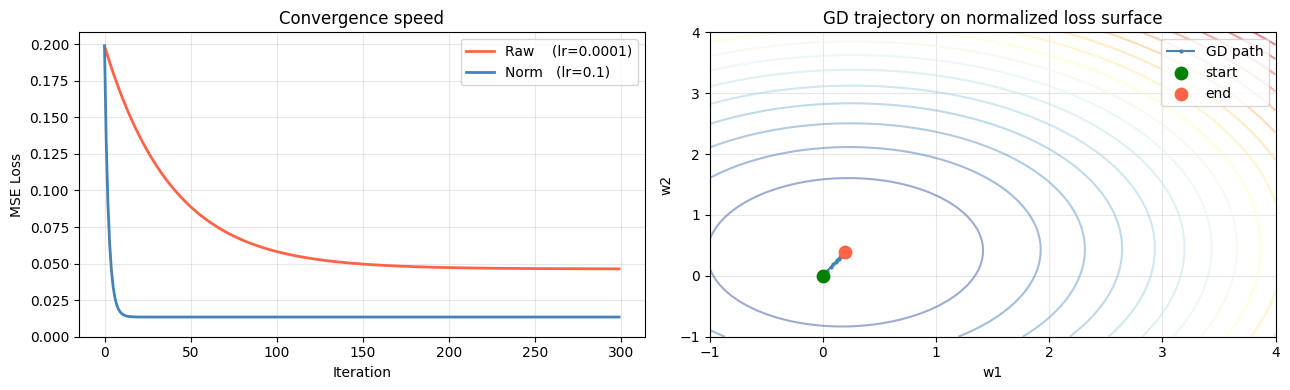

In [14]:
# ---- Convergence comparison: raw vs normalized ----
def gd_trace(X, y, lr, n_iter):
    """Returns weight history and loss history."""
    m_d, n_d = X.shape
    w = np.zeros(n_d)
    w_hist, loss_hist = [w.copy()], []
    for _ in range(n_iter):
        res = X @ w - y
        grad = (2/m_d) * X.T @ res
        w = w - lr * grad
        w_hist.append(w.copy())
        loss_hist.append(np.mean(res**2))
    return np.array(w_hist), loss_hist

w_hist_raw,  loss_raw  = gd_trace(X_raw,  y_c, lr=0.0001, n_iter=300)
w_hist_norm, loss_norm = gd_trace(X_norm, y_c, lr=0.1,    n_iter=300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(loss_raw,  lw=2, color='tomato',    label=f'Raw    (lr=0.0001)')
axes[0].plot(loss_norm, lw=2, color='steelblue', label=f'Norm   (lr=0.1)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Convergence speed')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Trajectory on contour (normalized case)
axes[1].contour(W1n, W2n, Zn, levels=20, cmap='RdYlBu_r', alpha=0.5)
axes[1].plot(w_hist_norm[:,0], w_hist_norm[:,1],
             'steelblue', lw=1.5, marker='o', markersize=2, label='GD path')
axes[1].scatter(*w_hist_norm[0], color='green', s=80, zorder=5, label='start')
axes[1].scatter(*w_hist_norm[-1], color='tomato', s=80, zorder=5, label='end')
axes[1].set_xlabel('w1'); axes[1].set_ylabel('w2')
axes[1].set_title('GD trajectory on normalized loss surface')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Gradient 공식: $\mathbf{X}^T$는 왜 나오는가?

### 3-1. 1변수에서 다변수로 — 패턴 관찰

4주차에서 1변수 gradient를 유도했습니다:

$$\frac{\partial L}{\partial w} = \frac{2}{m} \sum_{i=1}^m (wx_i - y_i) \cdot x_i = \frac{2}{m} \mathbf{x}^T \mathbf{r}$$

여기서 $\mathbf{r} = \mathbf{x}w - \mathbf{y}$는 잔차 벡터, $\mathbf{x}$는 특성 벡터입니다.

다변수로 확장하면 각 $w_j$에 대한 편미분이 필요합니다:

$$\frac{\partial L}{\partial w_j} = \frac{2}{m} \sum_{i=1}^m (\hat{y}_i - y_i) \cdot x_{ij} = \frac{2}{m} \mathbf{x}_j^T \mathbf{r}$$

$j$번째 특성 열 $\mathbf{x}_j$와 잔차 $\mathbf{r}$의 내적입니다. 이것을 모든 $j$에 대해 쌓으면:

$$\nabla_{\mathbf{w}} L = \begin{bmatrix} \frac{\partial L}{\partial w_0} \\ \frac{\partial L}{\partial w_1} \\ \vdots \\ \frac{\partial L}{\partial w_n} \end{bmatrix} = \frac{2}{m} \begin{bmatrix} \mathbf{x}_0^T \mathbf{r} \\ \mathbf{x}_1^T \mathbf{r} \\ \vdots \\ \mathbf{x}_n^T \mathbf{r} \end{bmatrix} = \frac{2}{m} \mathbf{X}^T \mathbf{r}$$

$$\boxed{\nabla_{\mathbf{w}} L = \frac{2}{m} \mathbf{X}^T (\mathbf{X}\mathbf{w} - \mathbf{y})}$$

**패턴:** 1변수에서 $x_i$ 하나였던 것이 다변수에서는 $\mathbf{X}^T$ 전체가 됩니다.  
$\mathbf{X}^T$는 각 행이 한 특성의 모든 샘플값 — 정확히 $\mathbf{x}_j^T$입니다.

### 3-2. $\mathbf{X}^T$의 기하적 의미

2주차 관점으로 돌아옵니다.

$$\underbrace{\mathbf{X}}_{\text{weight space} \to \text{prediction space}} \mathbf{w} = \hat{\mathbf{y}}$$

$\mathbf{w}$가 데이터 $\mathbf{X}$를 통해 prediction space의 벡터 $\hat{\mathbf{y}}$를 만들어냅니다.

> **왜 이렇게 읽나요?**  
> $\hat{y}_i = \mathbf{w}^T\mathbf{x}_i$ — 각 샘플 $\mathbf{x}_i$에 $\mathbf{w}$를 적용해서 스칼라 예측값을 만드는 것이므로,  
> $\mathbf{w}$가 변환의 주체이고 데이터가 변환되는 대상입니다.  
> 학습 중에는 $\mathbf{X}$가 고정되고 $\mathbf{w}$가 바뀌므로, weight space → prediction space 변환의 방향도 자연스럽게 연결됩니다.

그러면 $\mathbf{X}^T$는?

$$\underbrace{\mathbf{X}^T}_{\text{prediction space} \to \text{weight space}} \mathbf{r} = \text{gradient}$$

$\mathbf{X}^T$는 **반대 방향** — prediction space의 잔차 벡터를 weight space로 돌려보내는 변환입니다.

**직관:**
1. 잔차 $\mathbf{r} = \hat{\mathbf{y}} - \mathbf{y}$는 prediction space에서 '현재 오차 방향'입니다
2. $\mathbf{X}^T\mathbf{r}$는 그 오차를 weight space로 **투영**합니다
3. 결과가 gradient — '$\mathbf{w}$를 어느 방향으로 움직이면 오차가 커지는가'

이것이 딥러닝의 **역전파(backpropagation)**의 가장 단순한 형태입니다.  
순방향: $\mathbf{X}\mathbf{w}$ ($\mathbf{w}$가 데이터를 prediction space로 변환)  
역방향: $\mathbf{X}^T\mathbf{r}$ (오차를 prediction space에서 weight space로 역변환)

In [15]:
# ---- X^T: verify the shape story ----
m_v, n_v = 5, 3   # 5 samples, 3 features (including bias)
X_v = np.random.randn(m_v, n_v)
w_v = np.random.randn(n_v)
y_v = np.random.randn(m_v)

# Forward: weight space → prediction space
y_hat = X_v @ w_v          # shape: (5,)  — prediction space
r     = y_hat - y_v        # shape: (5,)  — residual in prediction space

# Backward: prediction space → weight space
grad = (2/m_v) * X_v.T @ r  # shape: (3,)  — gradient in weight space

print('X.shape  :', X_v.shape,    '  (m × n) — maps weight→prediction')
print('X.T.shape:', X_v.T.shape,  '  (n × m) — maps prediction→weight')
print()
print('w.shape  :', w_v.shape,    '  — in weight space')
print('r.shape  :', r.shape,      '  — in prediction space')
print('grad.shape:', grad.shape,  '  — back in weight space')
print()
print('X maps n→m, X.T maps m→n: the transpose reverses the direction.')

X.shape  : (5, 3)   (m × n) — maps weight→prediction
X.T.shape: (3, 5)   (n × m) — maps prediction→weight

w.shape  : (3,)   — in weight space
r.shape  : (5,)   — in prediction space
grad.shape: (3,)   — back in weight space

X maps n→m, X.T maps m→n: the transpose reverses the direction.


### 3-3. Gradient 공식 수치 검증

공식이 올바른지 수치 미분으로 확인합니다. (4주차에서 배운 방법)

In [17]:
# ---- Numerical verification of multivariate gradient ----
np.random.seed(3)
m_g, n_g = 10, 4   # 10 samples, 4 features (including bias)
X_g = np.hstack([np.ones((m_g,1)), np.random.randn(m_g, n_g-1)])
y_g = np.random.randn(m_g)
w_g = np.random.randn(n_g)

# Analytical gradient
r_g   = X_g @ w_g - y_g
grad_analytical = (2/m_g) * X_g.T @ r_g

# Numerical gradient (centered finite difference for each component)
eps = 1e-5
grad_numerical = np.zeros(n_g)
for j in range(n_g):
    w_plus  = w_g.copy(); w_plus[j]  += eps
    w_minus = w_g.copy(); w_minus[j] -= eps
    L_plus  = np.mean((X_g @ w_plus  - y_g)**2)
    L_minus = np.mean((X_g @ w_minus - y_g)**2)
    grad_numerical[j] = (L_plus - L_minus) / (2*eps)

print('Analytical gradient:', grad_analytical.round(6))
print('Numerical  gradient:', grad_numerical.round(6))
print('Max difference     :', np.max(np.abs(grad_analytical - grad_numerical)).round(6))
print('\n공식이 맞습니다.')

Analytical gradient: [-2.020586  2.197459 -0.240251 -2.363115]
Numerical  gradient: [-2.020586  2.197459 -0.240251 -2.363115]
Max difference     : 0.0

공식이 맞습니다.


---
## 4. 구현 — 1변수와 다변수 코드 비교

이제 Aha Moment의 질문에 답할 수 있습니다.  
1변수 gradient descent:

```python
grad = (2/m) * np.sum(residual * x)   # scalar
w    = w - lr * grad
```

다변수 gradient descent:

```python
grad = (2/m) * X.T @ residual         # vector
w    = w - lr * grad
```

$\sum r_i \cdot x_i$ (스칼라) → $\mathbf{X}^T\mathbf{r}$ (벡터)로 바꾼 것뿐입니다.  
수식 구조가 동일하므로 코드도 동일합니다.

In [14]:
# ---- Full pipeline: normalize → bias trick → GD → evaluate ----
np.random.seed(7)
m_f = 80

# True model: y = 2*x1 - 1.5*x2 + 0.8*x3 + 1 (bias)
X_raw_f = np.random.randn(m_f, 3)
y_f = 2*X_raw_f[:,0] - 1.5*X_raw_f[:,1] + 0.8*X_raw_f[:,2] + 1.0
y_f += np.random.randn(m_f) * 0.4

# Step 1: normalize (using training data statistics)
mu = X_raw_f.mean(axis=0)     # shape (3,)
sig = X_raw_f.std(axis=0)     # shape (3,)
X_n_f = (X_raw_f - mu) / sig  # broadcasting: shape (80, 3)

# Step 2: bias trick
X_b_f = np.hstack([np.ones((m_f, 1)), X_n_f])  # shape (80, 4)

# Step 3: gradient descent
def gd_full(X, y, lr=0.1, n_iter=100000):
    m_d, n_d = X.shape
    w = np.zeros(n_d)
    losses = []
    for _ in range(n_iter):
        residual = X @ w - y           # prediction error: shape (m,)
        grad = (2/m_d) * X.T @ residual  # gradient: shape (n,)
        w = w - lr * grad
        losses.append(np.mean(residual**2))
    return w, losses

w_final, losses = gd_full(X_b_f, y_f)

# Step 4: interpret results
print('Learned weights (after normalization):')
print(f'  bias: {w_final[0]:.3f}  (true: 1.0)')
print(f'  w1  : {w_final[1]:.3f}  (true: 2.0)')
print(f'  w2  : {w_final[2]:.3f}  (true: -1.5)')
print(f'  w3  : {w_final[3]:.3f}  (true: 0.8)')
print(f'\nFinal MSE: {losses[-1]:.4f}')

Learned weights (after normalization):
  bias: 1.299  (true: 1.0)
  w1  : 1.945  (true: 2.0)
  w2  : -1.379  (true: -1.5)
  w3  : 0.794  (true: 0.8)

Final MSE: 0.1589


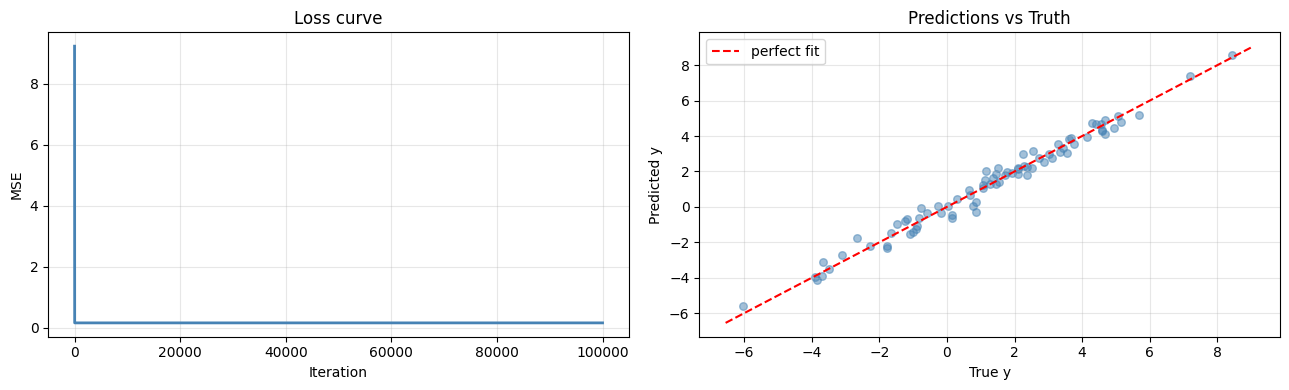

In [15]:
# ---- Visualize loss curve and weight convergence ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(losses, color='steelblue', lw=2)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE')
axes[0].set_title('Loss curve'); axes[0].grid(True, alpha=0.3)

# Check: predictions vs true values
y_pred = X_b_f @ w_final
axes[1].scatter(y_f, y_pred, alpha=0.5, s=30, color='steelblue')
lims = [min(y_f.min(), y_pred.min())-0.5, max(y_f.max(), y_pred.max())+0.5]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='perfect fit')
axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')
axes[1].set_title('Predictions vs Truth')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## [이 셀은 심화-시험 제외] Gradient를 0으로 놓으면 정규방정식(normal equation)이 나온다

> 이 섹션은 선택 사항입니다. 건너뛰어도 이후 수업에 영향이 없습니다.

gradient 공식을 다시 봅니다:

$$\nabla_{\mathbf{w}} L = \frac{2}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y})$$

최솟값에서는 gradient = **0** 이어야 합니다. 그러면:

$$\frac{2}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y}) = \mathbf{0}$$

$\frac{2}{m}$은 0이 아니므로 괄호 안이 0이어야 합니다:

$$\mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{X}^T\mathbf{y} = \mathbf{0}$$

$$\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$

양변 왼쪽에 $(\mathbf{X}^T\mathbf{X})^{-1}$을 곱하면:

$$\boxed{\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

**Lecture3에서 본 정규방정식과 동일합니다.**

---

**이것이 의미하는 바:**

| 방법 | 하는 일 | 비용 |
|------|---------|------|
| 정규방정식 | gradient = 0 방정식을 직접 풀어 $\mathbf{w}^*$를 한 번에 구함 | 역행렬 계산 — 특성 많으면 불가 |
| 경사하강법 | gradient 방향을 따라 조금씩 이동하며 $\mathbf{w}^*$에 접근 | 반복 계산 — 특성이 많아도 가능 |

두 방법은 **같은 문제를 다른 전략으로** 풀고 있습니다.  
경사하강법은 정규방정식을 풀 수 없을 때의 현실적 대안이 아니라,  
수학적으로 동등한 독립적인 방법입니다.

In [20]:
# [이 셀은 심화-시험 제외]
# ---- Verify: normal equation == GD solution ----
import numpy as np
np.random.seed(42)

m, n = 50, 3
X_raw = np.random.randn(m, n)

# 표준화(Standardization) + 편향 트릭
mu, sig = X_raw.mean(axis=0), X_raw.std(axis=0)
X_std = (X_raw - mu) / sig
X_b   = np.hstack([np.ones((m, 1)), X_std])   # shape (50, 4)

y = 2*X_std[:,0] - 1.5*X_std[:,1] + 0.8*X_std[:,2] + 1.0 + np.random.randn(m)*0.3

# Method 1: Normal Equation  w* = (X^T X)^{-1} X^T y
w_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Method 2: Gradient Descent
w_gd = np.zeros(X_b.shape[1])
for _ in range(2000):
    r = X_b @ w_gd - y
    w_gd = w_gd - 0.1 * (2/m) * X_b.T @ r

print('Normal Equation : ', w_normal.round(4))
print('Gradient Descent: ', w_gd.round(4))
print('Max difference  : ', np.max(np.abs(w_normal - w_gd)).round(6))
print()
print('두 방법이 같은 답에 수렴합니다.')

Normal Equation :  [ 1.0252  2.0299 -1.5423  0.8002]
Gradient Descent:  [ 1.0252  2.0299 -1.5423  0.8002]
Max difference  :  0.0

두 방법이 같은 답에 수렴합니다.


## 이제 심화를 마치고 다시 강의를 이어갑니다!

---
## 5. 특성을 추가하면 무슨 일이 생기는가?

특성이 많아질수록 모델의 표현력이 높아집니다.  
그러면 항상 더 좋아질까요?

선형 변환 관점으로 생각해봅니다:  
- 특성 1개: $\mathbf{X}_{m\times2}$ — 가중치 공간은 2차원
- 특성 3개: $\mathbf{X}_{m\times4}$ — 가중치 공간은 4차원

가중치 공간이 커질수록 손실함수의 등고선은 더 고차원이 됩니다.  
찾아야 할 최솟점도 더 복잡한 공간에 있게 됩니다.

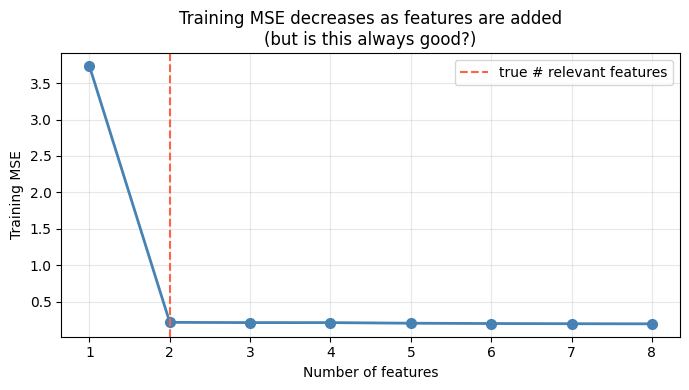

훈련 MSE가 계속 줄어듭니다.
→ 그런데 관련 없는 특성(3번~8번)을 추가했는데도 MSE가 줄어드는 이유는?
→ 6주차 주제: 과적합과 정규화


In [21]:
# ---- Effect of adding features: MSE vs number of features ----
np.random.seed(9)
m_e = 50

# Only 2 features are truly relevant
X_all = np.random.randn(m_e, 8)
y_e = 3*X_all[:,0] - 2*X_all[:,1] + np.random.randn(m_e)*0.5

train_mses, feat_counts = [], []
for n_feat in range(1, 9):
    X_sub = X_all[:, :n_feat]
    X_sub = (X_sub - X_sub.mean(axis=0)) / X_sub.std(axis=0)
    X_sub = np.hstack([np.ones((m_e,1)), X_sub])
    w_e, loss_e = gd_full(X_sub, y_e, lr=0.1, n_iter=1000)
    train_mses.append(loss_e[-1])
    feat_counts.append(n_feat)

plt.figure(figsize=(7, 4))
plt.plot(feat_counts, train_mses, 'o-', color='steelblue', lw=2, markersize=7)
plt.axvline(x=2, color='tomato', ls='--', lw=1.5, label='true # relevant features')
plt.xlabel('Number of features'); plt.ylabel('Training MSE')
plt.title('Training MSE decreases as features are added\n(but is this always good?)')
plt.xticks(feat_counts); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('훈련 MSE가 계속 줄어듭니다.')
print('→ 그런데 관련 없는 특성(3번~8번)을 추가했는데도 MSE가 줄어드는 이유는?')
print('→ 6주차 주제: 과적합과 정규화')

---
## 🎯 Aha Moment 닫기

처음 질문: 특성이 1개든 4개든 `gd()` 함수가 왜 동일한가?

**답:** $\nabla L = \frac{2}{m}\mathbf{X}^T\mathbf{r}$ 공식의 구조가 특성 수에 무관하기 때문입니다.

- $\mathbf{X}$의 열이 1개든 100개든, $\mathbf{X}^T\mathbf{r}$는 항상 gradient 벡터를 반환합니다
- 이는 $\mathbf{X}^T$가 잔차(예측 공간)를 gradient(가중치 공간)로 변환하는 선형 변환이기 때문입니다
- 특성이 늘어난다는 것 = $\mathbf{X}$에 열이 추가된다는 것 = 가중치 공간의 차원이 늘어난다는 것

$$\text{1변수: } \frac{2}{m}\mathbf{x}^T\mathbf{r} \quad\longrightarrow\quad \text{다변수: } \frac{2}{m}\mathbf{X}^T\mathbf{r}$$

같은 구조, 다른 차원 — 이것이 행렬 표기법의 힘입니다.

---
## ✏️ 익히기 활동 (25분)

### 문제 1: Gradient 공식의 shape 추적 (8분)

$m = 6$개 샘플, $n = 2$개 특성(+편향)이 있습니다.  
즉 $\mathbf{X}$의 shape은 $(6, 3)$, $\mathbf{w}$의 shape은 $(3,)$입니다.

$\nabla L = \frac{2}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y})$ 계산 과정에서 각 단계의 shape을 채우세요.

| 단계 |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 수식&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | shape |
|------|------|-------|
| 1 | $\mathbf{X}\mathbf{w}$ | $(\quad, \quad)$ → $(\quad,)$ |
| 2 | $\mathbf{X}\mathbf{w} - \mathbf{y}$ | $(\quad,)$ |
| 3 | $\mathbf{X}^T$ | $(\quad, \quad)$ |
| 4 | $\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$ | $(\quad,)$ |
| 5 | $\frac{2}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$ | $(\quad,)$ — gradient |

최종 gradient의 shape은 $\mathbf{w}$의 shape $(3,)$과 같아야 합니다. 맞나요? ______

In [3]:
# Problem 1: verify your shape predictions
m_p, n_p = 6, 3   # 6 samples, 3 cols in X (bias + 2 features)
X_p = np.random.randn(m_p, n_p)
w_p = np.random.randn(n_p)
y_p = np.random.randn(m_p)

step1 = X_p @ w_p
step2 = step1 - y_p
step3 = X_p.T              # X^T
step4 = X_p.T @ step2
step5 = (2/m_p) * step4

print('Step 1: X @ w           shape:', step1.shape)
print('Step 2: Xw - y           shape:', step2.shape)
print('Step 3: X.T              shape:', step3.shape)
print('Step 4: X.T @ (Xw-y)    shape:', step4.shape)
print('Step 5: (2/m)*X.T@(Xw-y) shape:', step5.shape)
print('\nw.shape:', w_p.shape, '— gradient shape should match w shape?', step5.shape == w_p.shape)

Step 1: X @ w           shape: (6,)
Step 2: Xw - y           shape: (6,)
Step 3: X.T              shape: (3, 6)
Step 4: X.T @ (Xw-y)    shape: (3,)
Step 5: (2/m)*X.T@(Xw-y) shape: (3,)

w.shape: (3,) — gradient shape should match w shape? True


### 문제 2: 전체 파이프라인 빈칸 (7분)

In [ ]:
# Problem 2: Complete the full pipeline
np.random.seed(11)
m_q, n_q = 40, 3
X_q_raw = np.random.randn(m_q, n_q) * np.array([1., 5., 0.2])   # different scales!
y_q = 2*X_q_raw[:,0] + X_q_raw[:,1]*0.3 - X_q_raw[:,2] + np.random.randn(m_q)*0.3

# Step 1: normalize
q_mu  = np.mean(X_q_raw, axis=0) # mean of each feature
q_sig = np.std(X_q_raw, axis=0)          # std  of each feature
X_q_n = (X_q_raw - q_mu) / q_sig

# Step 2: bias trick
X_q_b = np.hstack([np.ones((m_q,1)), X_q_n])   # prepend ones column

# Step 3: gradient descent
m_d, n_d = X_q_b.shape
w_q = np.zeros(n_d)
lr_q = 0.1

for _ in range(500):
    residual = X_q_b @ w_q - y_q
    grad = (2/m_q) * (X_q_b.T @ residual)   # fill in the gradient formula
    w_q = w_q - lr_q * grad

print('Final MSE:', np.mean((X_q_b @ w_q - y_q)**2).round(4))
print('Weights:', w_q.round(3))

Final MSE: 0.0614
Weights: [-0.493  2.009  1.294 -0.162]


### 🐛 버그 문제 (10분)

아래 코드는 실행되지만 gradient가 잘못 계산되어 손실이 수렴하지 않습니다.  
팀원과 논의하며 버그를 찾고 원인을 수학적으로 설명하세요.

*교실에서 팀 활동으로 해결합니다.*

(3,)


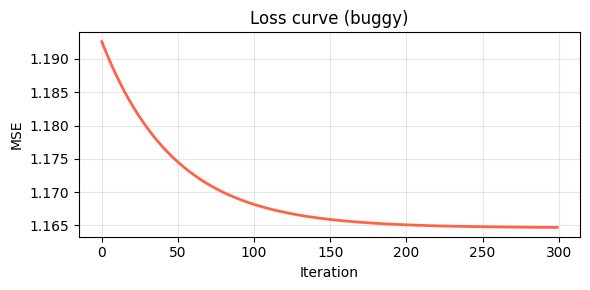

In [ ]:
# 🐛 Bug Hunt: GD runs but loss does not decrease properly
np.random.seed(5)
m_b, n_b = 30, 3
X_b_bug = np.hstack([np.ones((m_b,1)),
                     np.random.randn(m_b, n_b-1)])
y_b = np.random.randn(m_b)

w_bug = np.zeros(n_b)
losses_bug = []

for _ in range(300):
    residual = X_b_bug @ w_bug - y_b
    grad = (2/m_b) * X_b_bug.T @ residual    # 🐛 spot the error
    w_bug = w_bug - 0.01 * grad
    losses_bug.append(np.mean(residual**2))

print(grad.shape)
plt.figure(figsize=(6,3))
plt.plot(losses_bug, color='tomato', lw=2)
plt.xlabel('Iteration'); plt.ylabel('MSE')
plt.title('Loss curve (buggy)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 버그 원인:  transpose안취함
# 수학적 설명: transpose안취하여 행렬곱셈 차원이 맞지 않음
# shape 확인: X_b_bug @ residual 의 shape = (3,1)(틀림!!!!! y_b가 1차원배열임을 인지해라!!!!)  (이어야 하는가?)

---
## 🤖 LLM 파트너 가이드

### 프롬프트 1: $\mathbf{X}^T$ 의미 확인
```
다변수 선형회귀 gradient에서 X^T가 등장하는 이유를 설명해주세요.
X가 가중치 공간에서 예측 공간으로 가는 변환이라면
X^T는 어느 방향의 변환인지, 잔차와의 관계를 중심으로 설명해 주세요.
```

### 프롬프트 2: shape 오류 디버깅
```
gradient descent 코드에서 ValueError가 발생합니다.
X.T @ residual 부분을 의심하는데,
답을 알려주기 전에 각 배열의 shape을 확인하는 방법부터 알려주세요.
[코드]
```

### 프롬프트 3: 손실 등고선 직관
```
특성 스케일이 다를 때 손실 등고선이 타원이 되는 이유를
MSE 수식과 연결해서 설명해주세요.
왜 타원이 길쭉할수록 경사하강법이 느려지나요?
```

> **원칙:** shape 오류가 나면 LLM에 바로 던지기 전에,  
> `print(A.shape)`로 각 단계의 shape을 확인하고 어느 단계에서 틀렸는지 좁힌 뒤 물어보세요.

---
## 📌 다음 주 예고: 과적합과 정규화

이번 주 마지막 시각화에서 봤습니다 — 관련 없는 특성을 추가해도 훈련 MSE가 줄어듭니다.  
이게 진짜 좋아지는 것일까요?

6주차 핵심 질문:
$$L(\mathbf{w}) = \underbrace{\frac{1}{m}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|^2}_{\text{MSE}} + \underbrace{\lambda \cdot \text{penalty}(\mathbf{w})}_{\text{?}}$$

손실함수에 $\mathbf{w}$의 **노름**을 더하면 gradient가 어떻게 바뀌고,  
최솟값의 위치가 어디로 이동하는지 — 기하적으로 살펴봅니다.